**Major Project: Seasonal Agriculture Performance Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

Dataset Loading & Intial Assessment

In [2]:
# Load dataset
df = pd.read_excel('seasonal_agriculture_performance_dataset.xlsx')

# Inspect dimensions and missingness
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (4000, 28)

Missing Values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


Data Cleaning & Feature Engineering

In [3]:
# Impute missing values using group medians
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df['Yield_Tonnes_Ha'] = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

# Engineer domain-specific KPIs
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Ha'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Ha'] = df['Revenue_INR'] / df['Farm_Area_Hectares']

Visualizations & Hypotheses Verification

/tmp/ipykernel_1644/2256304127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_1644/2256304127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_1644/2256304127.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=axes[1, 0], palette='Set2')


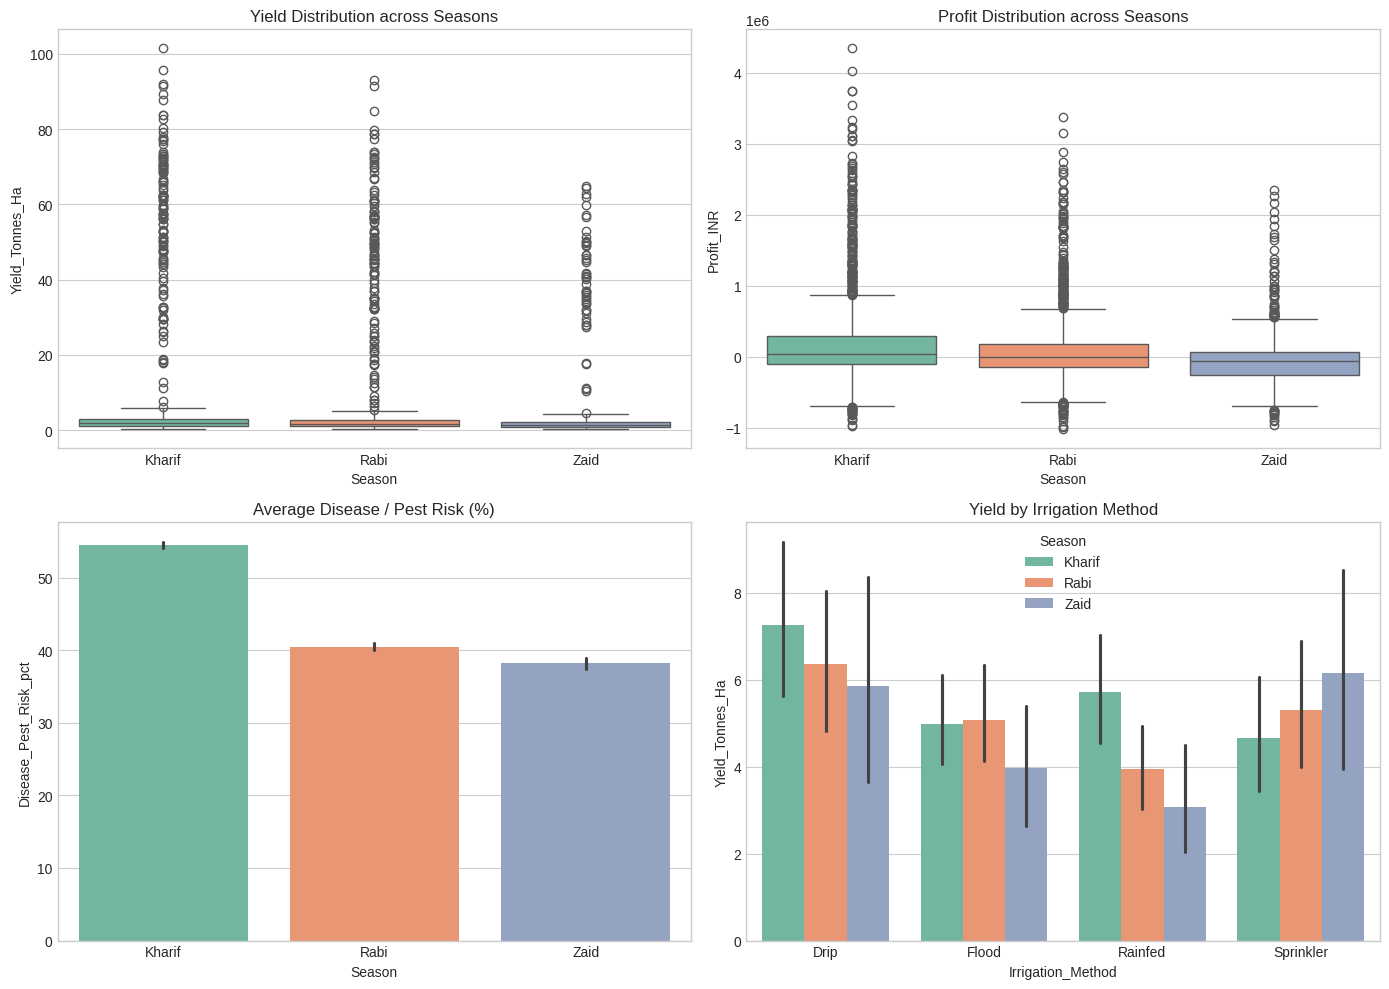

In [4]:
# Multi-panel visualization plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Yield Distribution across Seasons')

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Profit Distribution across Seasons')

sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Average Disease / Pest Risk (%)')

sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Yield by Irrigation Method')

plt.tight_layout()
plt.show()

Final Recommendations

Transition Off-Season Irrigation: Incentivize Drip/Sprinkler adoption during Zaid to improve crop survival and control input costs.

Disease Mitigation: Implement early pest monitoring and preventive spraying protocols during Kharif to combat humidity-driven outbreaks.

Targeted Price Supports: Re-evaluate market price dynamics and subsidies for staple food crops (Wheat/Rice) to protect farmers from seasonal losses.